<a href="https://colab.research.google.com/github/Kritika-Dhiman/nba-finals-predictor/blob/main/NBA_Finals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nba_api
import pandas as pd
import numpy as np
import time
from nba_api.stats.endpoints import leaguegamelog, teamgamelogs
from nba_api.stats.static import teams
print("All packages installed and imported")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 6.3 MB/s eta 0:00:00
All packages installed and imported


In [ ]:
all_teams=teams.get_teams()
teams_df=pd.DataFrame(all_teams)
print(f'Total teams : {len(teams_df)}')
print()
print(teams_df[['id','abbreviation','full_name','city']].to_string(index=False))

Total teams : 30

        id abbreviation              full_name          city
1610612737          ATL          Atlanta Hawks       Atlanta
1610612738          BOS         Boston Celtics        Boston
1610612739          CLE    Cleveland Cavaliers     Cleveland
1610612740          NOP   New Orleans Pelicans   New Orleans
1610612741          CHI          Chicago Bulls       Chicago
1610612742          DAL       Dallas Mavericks        Dallas
1610612743          DEN         Denver Nuggets        Denver
1610612744          GSW  Golden State Warriors San Francisco
1610612745          HOU        Houston Rockets       Houston
1610612746          LAC   Los Angeles Clippers   Los Angeles
1610612747          LAL     Los Angeles Lakers   Los Angeles
1610612748          MIA             Miami Heat         Miami
1610612749          MIL        Milwaukee Bucks     Milwaukee
1610612750          MIN Minnesota Timberwolves     Minnesota
1610612751          BKN          Brooklyn Nets      Brooklyn
161061

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 1.4 MB/s eta 0:00:00
Season: 2022-23
 Fetching2022-23vRegular Season..  Rows : 2460
 Fetching2022-23vPlayoffs..  Rows : 168
Season: 2023-24
 Fetching2023-24vRegular Season..  Rows : 2460
 Fetching2023-24vPlayoffs..  Rows : 164
Season: 2024-25
 Fetching2024-25vRegular Season..  Rows : 2460
 Fetching2024-25vPlayoffs..  Rows : 168
Season: 2025-26
 Fetching2025-26vRegular Season..  Rows : 2460
 Fetching2025-26vPlayoffs..  Rows : 164
Total rows collected : 10504
Columns : ['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE', 'SEASON', 'SEASON_TYPE']
Shape:  (10504, 31)

Col Description
  SEASON_ID             ->Internal season identifier
  TEAM_ID               ->Unique team ID
  TEAM_ABBREVIATION     ->e.g. NYK

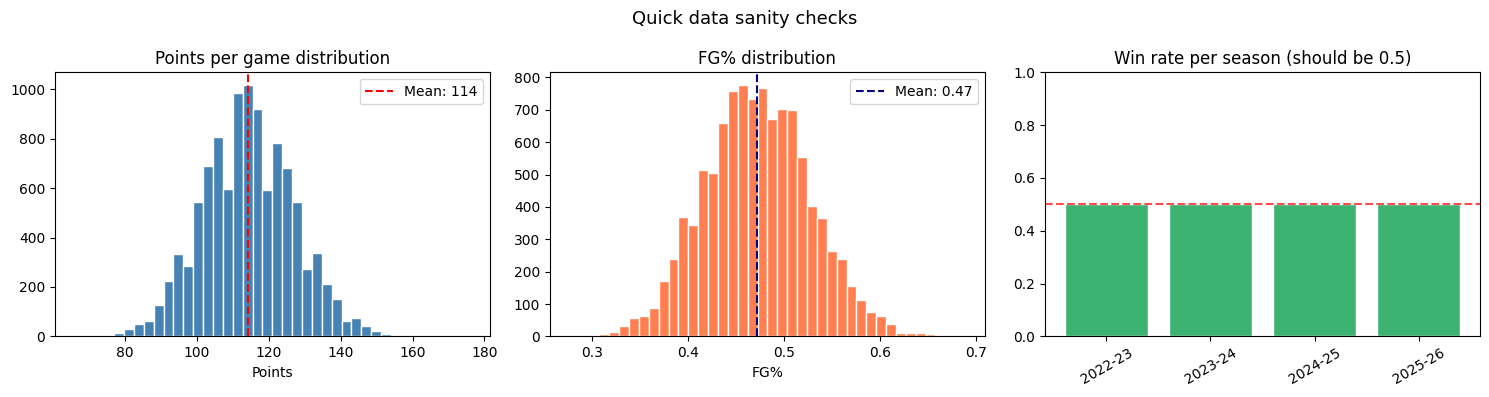

In [4]:
!pip install nba_api
import numpy as np
import pandas as pd
import time
from nba_api.stats.endpoints import leaguegamelog
from nba_api.stats.static import teams


def fetch_season_games(season:str, season_type:str)->pd.DataFrame:
  print(f' Fetching{season}v{season_type}..', end=' ')
  try:
    log=leaguegamelog.LeagueGameLog(
        season=season,
        season_type_all_star=season_type,
        league_id='00'
    )
    df=log.get_data_frames()[0]
    df['SEASON']=season
    df['SEASON_TYPE']=season_type
    print(f' Rows : {len(df)}')
    return df
  except Exception as e:
    print(f'Error:{e}')
    return pd.DataFrame()

seasons=['2022-23','2023-24','2024-25','2025-26']
all_games=[]
for season in seasons:
  print(f'Season: {season}')
  reg=fetch_season_games(season, 'Regular Season')
  if not reg.empty:
    all_games.append(reg)

  time.sleep(1.5)
  play=fetch_season_games(season, 'Playoffs')
  if not play.empty:
    all_games.append(play)
  time.sleep(1.5)

raw_df=pd.concat(all_games,ignore_index=True)
print(f'Total rows collected : {len(raw_df)}')
print(f'Columns : {list(raw_df.columns)}')
print('Shape: ', raw_df.shape)
print()
print('Col Description')
col_descriptions={
    'SEASON_ID'    : 'Internal season identifier',
    'TEAM_ID'      : 'Unique team ID',
    'TEAM_ABBREVIATION': 'e.g. NYK, SAS, OKC',
    'TEAM_NAME'    : 'Full team name',
    'GAME_ID'      : 'Unique game ID — use this to join home vs away',
    'GAME_DATE'    : 'Date played',
    'MATCHUP'      : 'e.g. NYK vs. SAS (home) or NYK @ SAS (away)',
    'WL'           : 'W = won, L = lost — this is our TARGET variable',
    'PTS'          : 'Points scored',
    'FG_PCT'       : 'Field goal percentage',
    'FG3_PCT'      : '3-point percentage',
    'FT_PCT'       : 'Free throw percentage',
    'REB'          : 'Total rebounds',
    'AST'          : 'Assists',
    'STL'          : 'Steals',
    'BLK'          : 'Blocks',
    'TOV'          : 'Turnovers',
    'PLUS_MINUS'   : '+/- point differential',
}
for col,desc in col_descriptions.items(): # Changed to .items()
  if col in raw_df.columns:
    print(f'  {col:<22}->{desc}')
print()
raw_df.head(4)

finals_check=raw_df[
    (raw_df['SEASON']=='2025-26') &
    (raw_df['SEASON_TYPE']=='Playoffs') &
    (raw_df['TEAM_ABBREVIATION'].isin(['NYK','SAS']))
].copy()
finals_check=finals_check.sort_values('GAME_DATE')
print(f'NYK+SAS playoff rows in 2025-26: {len(finals_check)}')
print()
print(finals_check[['GAME_DATE','TEAM_ABBREVIATION','MATCHUP','WL','PTS', 'FG_PCT', 'REB', 'AST', 'TOV', 'PLUS_MINUS']].to_string(index=False))

print('Data Quality Check')
print()
missing=raw_df.isnull().sum()
missing_pct=(missing/len(raw_df)*100).round(2)
missing_report=pd.DataFrame({'missing_count':missing, 'missing_pct':missing_pct})
print(missing_report[missing_report['missing_count']>0])

print('(blank=no missing val in that col)')
print()

unique_games=raw_df['GAME_ID'].nunique()
print(f'Unique games : {unique_games:,}')
print(f'Total rows(2 per game) : {len(raw_df):,}')
print(f'Sanity check (rows ÷ 2 ≈ unique games): {len(raw_df)//2:,}')
print()
print('Rows per season + type:')
print(raw_df.groupby(['SEASON', 'SEASON_TYPE']).size().to_string())
print()
print('Win/Loss distribution:')
print(raw_df['WL'].value_counts())
print('(Should be roughly 50/50 — every W has a matching L)')

raw_df['IS_HOME']=raw_df['MATCHUP'].apply(lambda x:1 if 'vs.' in x else 0)
print('IS_HOME distribution:')
print(raw_df['IS_HOME'].value_counts())
print()
print('Sample rows to verify logic:')
print(raw_df[['MATCHUP', 'IS_HOME']].head(10).to_string(index=False))
# Convert W/L string to 1/0
raw_df['WIN'] = (raw_df['WL'] == 'W').astype(int)

print('WIN column (our target variable):')
print(raw_df['WIN'].value_counts())
print()
home_winrate = raw_df[raw_df['IS_HOME'] == 1]['WIN'].mean()
away_winrate = raw_df[raw_df['IS_HOME'] == 0]['WIN'].mean()
print(f'Home team win rate: {home_winrate:.1%}  ← should be ~58-62%')
print(f'Away team win rate: {away_winrate:.1%}  ← should be ~38-42%')
print()
print(' Home court advantage confirmed in the data' if home_winrate > 0.55 else ' Unexpected — double-check MATCHUP parsing')
# Keep only the columns we actually need for modeling
columns_to_keep = [
    # Identifiers
    'GAME_ID', 'GAME_DATE', 'SEASON', 'SEASON_TYPE',
    # Team info
    'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME',
    # Game context
    'MATCHUP', 'IS_HOME',
    # Performance stats (our features)
    'PTS', 'FG_PCT', 'FG3_PCT', 'FT_PCT',
    'REB', 'AST', 'STL', 'BLK', 'TOV', 'PLUS_MINUS',
    # Target variable
    'WIN'
]

clean_df = raw_df[columns_to_keep].copy()

# Sort by date
clean_df['GAME_DATE'] = pd.to_datetime(clean_df['GAME_DATE'])
clean_df = clean_df.sort_values('GAME_DATE').reset_index(drop=True)

# Save to CSV
clean_df.to_csv('nba_games_raw.csv', index=False)

print(f'Saved nba_games_raw.csv')
print(f'   Rows : {len(clean_df):,}')
print(f'   Cols : {len(clean_df.columns)}')
print(f'   Date range: {clean_df["GAME_DATE"].min().date()} → {clean_df["GAME_DATE"].max().date()}')
print()
print('Preview:')
clean_df.head(5)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Quick data sanity checks', fontsize=13)

# 1. Points distribution
axes[0].hist(clean_df['PTS'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(clean_df['PTS'].mean(), color='red', linestyle='--', label=f'Mean: {clean_df["PTS"].mean():.0f}')
axes[0].set_title('Points per game distribution')
axes[0].set_xlabel('Points')
axes[0].legend()

# 2. FG% distribution
axes[1].hist(clean_df['FG_PCT'], bins=40, color='coral', edgecolor='white')
axes[1].axvline(clean_df['FG_PCT'].mean(), color='navy', linestyle='--', label=f'Mean: {clean_df["FG_PCT"].mean():.2f}')
axes[1].set_title('FG% distribution')
axes[1].set_xlabel('FG%')
axes[1].legend()

# 3. Win rate by season
# (should always be 0.5 since every W has a matching L)
win_by_season = clean_df.groupby('SEASON')['WIN'].mean()
axes[2].bar(win_by_season.index, win_by_season.values, color='mediumseagreen', edgecolor='white')
axes[2].axhline(0.5, color='red', linestyle='--', alpha=0.7)
axes[2].set_title('Win rate per season (should be 0.5)')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


Loaded: 10,504 rows × 20 columns
Date range: 2022-10-18 → 2026-06-05

Before merge : 10,504 rows (2 per game)
After merge  : 5,242 rows (1 per game)

Columns now:
['GAME_ID', 'GAME_DATE', 'SEASON', 'SEASON_TYPE', 'HOME_TEAM_ID', 'HOME_TEAM_ABBREVIATION', 'HOME_TEAM_NAME', 'HOME_PTS', 'HOME_FG_PCT', 'HOME_FG3_PCT', 'HOME_FT_PCT', 'HOME_REB', 'HOME_AST', 'HOME_STL', 'HOME_BLK', 'HOME_TOV', 'HOME_PLUS_MINUS', 'HOME_WIN', 'AWAY_TEAM_ID', 'AWAY_TEAM_ABBREVIATION', 'AWAY_TEAM_NAME', 'AWAY_PTS', 'AWAY_FG_PCT', 'AWAY_FG3_PCT', 'AWAY_FT_PCT', 'AWAY_REB', 'AWAY_AST', 'AWAY_STL', 'AWAY_BLK', 'AWAY_TOV', 'AWAY_PLUS_MINUS', 'AWAY_WIN']

NYK rolling stats (last 15 games):
 GAME_DATE  PTS  ROLL_PTS  WIN  ROLL_WIN_RATE
2026-04-20  106     110.4    0            0.6
2026-04-23  108     110.7    0            0.6
2026-04-25  114     111.5    1            0.6
2026-04-28  126     113.5    1            0.7
2026-04-30  140     113.1    1            0.7
2026-05-04  137     113.5    1            0.7
2026-05-06 

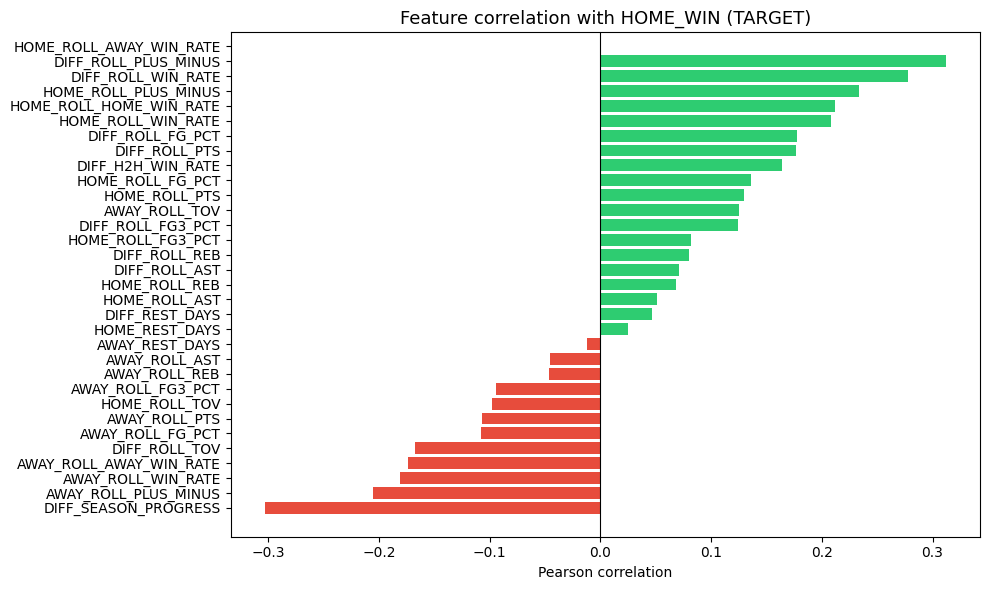

Top 5 positive predictors of home team winning:
HOME_ROLL_AWAY_WIN_RATE   NaN
AWAY_ROLL_HOME_WIN_RATE   NaN
DIFF_ROLL_HOME_WIN_RATE   NaN
DIFF_ROLL_AWAY_WIN_RATE   NaN
DIFF_IS_PLAYOFF           NaN

Top 5 negative predictors (away team advantage):
DIFF_SEASON_PROGRESS      -0.303098
AWAY_ROLL_PLUS_MINUS      -0.205477
AWAY_ROLL_WIN_RATE        -0.181012
AWAY_ROLL_AWAY_WIN_RATE   -0.173427
DIFF_ROLL_TOV             -0.167078
 Saved nba_games_features.csv
   Rows    : 5,242
   Columns : 51

Model feature count: 38
Features: ['HOME_ROLL_PTS', 'HOME_ROLL_FG_PCT', 'HOME_ROLL_FG3_PCT', 'HOME_ROLL_REB', 'HOME_ROLL_AST', 'HOME_ROLL_TOV', 'HOME_ROLL_PLUS_MINUS', 'HOME_ROLL_WIN_RATE', 'HOME_REST_DAYS', 'HOME_ROLL_HOME_WIN_RATE', 'HOME_ROLL_AWAY_WIN_RATE', 'HOME_IS_PLAYOFF', 'AWAY_ROLL_PTS', 'AWAY_ROLL_FG_PCT', 'AWAY_ROLL_FG3_PCT', 'AWAY_ROLL_REB', 'AWAY_ROLL_AST', 'AWAY_ROLL_TOV', 'AWAY_ROLL_PLUS_MINUS', 'AWAY_ROLL_WIN_RATE', 'AWAY_REST_DAYS', 'AWAY_ROLL_HOME_WIN_RATE', 'AWAY_ROLL_AWAY_WIN_RATE'

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('nba_games_raw.csv', parse_dates=['GAME_DATE'])
df = df.sort_values('GAME_DATE').reset_index(drop=True)

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range: {df["GAME_DATE"].min().date()} → {df["GAME_DATE"].max().date()}')
print()
df.head(4)
# Split into home and away dataframes
home = df[df['IS_HOME'] == 1].copy()
away = df[df['IS_HOME'] == 0].copy()

# Rename columns so after merging we know which team is which
stat_cols = ['TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME',
             'PTS', 'FG_PCT', 'FG3_PCT', 'FT_PCT',
             'REB', 'AST', 'STL', 'BLK', 'TOV', 'PLUS_MINUS', 'WIN']

home_renamed = home[['GAME_ID', 'GAME_DATE', 'SEASON', 'SEASON_TYPE'] + stat_cols].copy()
home_renamed.columns = ['GAME_ID', 'GAME_DATE', 'SEASON', 'SEASON_TYPE'] + [f'HOME_{c}' for c in stat_cols]

away_renamed = away[['GAME_ID'] + stat_cols].copy()
away_renamed.columns = ['GAME_ID'] + [f'AWAY_{c}' for c in stat_cols]

# Merge on GAME_ID
games = home_renamed.merge(away_renamed, on='GAME_ID')
games = games.sort_values('GAME_DATE').reset_index(drop=True)

# HOME_WIN is our target (1 = home team won, 0 = away team won)
# Already captured in HOME_WIN column

print(f'Before merge : {len(df):,} rows (2 per game)')
print(f'After merge  : {len(games):,} rows (1 per game)')
print()
print('Columns now:')
print([c for c in games.columns])
print()
games.head(3)
# Stats to compute rolling averages for
ROLL_STATS = ['PTS', 'FG_PCT', 'FG3_PCT', 'REB', 'AST', 'TOV', 'PLUS_MINUS']
WINDOW = 10  # last 10 games

def add_rolling_features(games_df, team_col, stat_cols, window=10):
    """
    For each team, compute rolling mean of the last `window` games.
    Uses shift(1) to avoid leakage (current game excluded from its own average).
    """
    result = games_df.copy()

    # We need to work on the per-team level using the raw (pre-merge) dataframe
    # so let's use the original df from Step 1
    raw = df.sort_values(['TEAM_ID', 'GAME_DATE']).copy()

    roll_features = {}

    for stat in stat_cols:
        if stat not in raw.columns:
            continue
        # For each team, rolling mean of past `window` games
        roll_col = raw.groupby('TEAM_ID')[stat].transform(
            lambda x: x.shift(1).rolling(window, min_periods=3).mean()
        )
        raw[f'ROLL_{stat}'] = roll_col

    # Also compute rolling WIN RATE
    raw['ROLL_WIN_RATE'] = raw.groupby('TEAM_ID')['WIN'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=3).mean()
    )

    return raw

raw_with_rolling = add_rolling_features(games, 'TEAM_ID', ROLL_STATS, WINDOW)

# Verify it worked
sample = raw_with_rolling[raw_with_rolling['TEAM_ABBREVIATION'] == 'NYK'][
    ['GAME_DATE', 'PTS', 'ROLL_PTS', 'WIN', 'ROLL_WIN_RATE']
].tail(15)
print('NYK rolling stats (last 15 games):')
print(sample.to_string(index=False))
raw_with_rolling = raw_with_rolling.sort_values(['TEAM_ID', 'GAME_DATE'])

raw_with_rolling['PREV_GAME_DATE'] = raw_with_rolling.groupby('TEAM_ID')['GAME_DATE'].shift(1)
raw_with_rolling['REST_DAYS'] = (
    raw_with_rolling['GAME_DATE'] - raw_with_rolling['PREV_GAME_DATE']
).dt.days

# First game of the season has no previous — fill with median (typically 2-3 days)
median_rest = raw_with_rolling['REST_DAYS'].median()
raw_with_rolling['REST_DAYS'] = raw_with_rolling['REST_DAYS'].fillna(median_rest)

# Cap at 10 days (long breaks like All-Star week shouldn't skew the model)
raw_with_rolling['REST_DAYS'] = raw_with_rolling['REST_DAYS'].clip(upper=10)

# Check
print('Rest days distribution:')
print(raw_with_rolling['REST_DAYS'].value_counts().sort_index())
print()

# Quick insight: does rest affect winning?
rest_win = raw_with_rolling.groupby('REST_DAYS')['WIN'].mean().reset_index()
rest_win.columns = ['REST_DAYS', 'WIN_RATE']
print('Win rate by rest days:')
print(rest_win[rest_win['REST_DAYS'] <= 7].to_string(index=False))
home_games = raw_with_rolling[raw_with_rolling['IS_HOME'] == 1].copy()
home_games['ROLL_HOME_WIN_RATE'] = home_games.groupby('TEAM_ID')['WIN'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=3).mean()
)

# Away win rate (rolling, last 10 away games)
away_games = raw_with_rolling[raw_with_rolling['IS_HOME'] == 0].copy()
away_games['ROLL_AWAY_WIN_RATE'] = away_games.groupby('TEAM_ID')['WIN'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=3).mean()
)

# Merge back
home_split = home_games[['GAME_ID', 'TEAM_ID', 'ROLL_HOME_WIN_RATE']]
away_split = away_games[['GAME_ID', 'TEAM_ID', 'ROLL_AWAY_WIN_RATE']]

raw_with_rolling = raw_with_rolling.merge(home_split, on=['GAME_ID', 'TEAM_ID'], how='left')
raw_with_rolling = raw_with_rolling.merge(away_split, on=['GAME_ID', 'TEAM_ID'], how='left')

# Show current season home/away win rates for NYK and SAS
for team in ['NYK', 'SAS']:
    t = raw_with_rolling[
        (raw_with_rolling['TEAM_ABBREVIATION'] == team) &
        (raw_with_rolling['SEASON'] == '2025-26')
    ]
    home_wr = t[t['IS_HOME']==1]['WIN'].mean()
    away_wr = t[t['IS_HOME']==0]['WIN'].mean()
    print(f'{team}  Home win rate: {home_wr:.1%}  |  Away win rate: {away_wr:.1%}')
    raw_sorted = raw_with_rolling.sort_values(['TEAM_ID', 'GAME_DATE']).copy()

# Get opponent ID from the merged games dataframe
# Map GAME_ID → opponent team for each team
game_opponents = pd.concat([
    games[['GAME_ID', 'HOME_TEAM_ID', 'AWAY_TEAM_ID']].rename(
        columns={'HOME_TEAM_ID': 'TEAM_ID', 'AWAY_TEAM_ID': 'OPP_TEAM_ID'}
    ),
    games[['GAME_ID', 'AWAY_TEAM_ID', 'HOME_TEAM_ID']].rename(
        columns={'AWAY_TEAM_ID': 'TEAM_ID', 'HOME_TEAM_ID': 'OPP_TEAM_ID'}
    )
])

raw_sorted = raw_sorted.merge(game_opponents, on=['GAME_ID', 'TEAM_ID'], how='left')

# Compute rolling H2H win rate (last 3 meetings vs same opponent)
raw_sorted = raw_sorted.sort_values(['TEAM_ID', 'OPP_TEAM_ID', 'GAME_DATE'])
raw_sorted['H2H_WIN_RATE'] = raw_sorted.groupby(['TEAM_ID', 'OPP_TEAM_ID'])['WIN'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

# Check NYK vs SAS head to head
nyk_id = df[df['TEAM_ABBREVIATION'] == 'NYK']['TEAM_ID'].iloc[0]
sas_id = df[df['TEAM_ABBREVIATION'] == 'SAS']['TEAM_ID'].iloc[0]

h2h = raw_sorted[
    (raw_sorted['TEAM_ID'] == nyk_id) &
    (raw_sorted['OPP_TEAM_ID'] == sas_id)
][['GAME_DATE', 'WIN', 'H2H_WIN_RATE']].tail(6)

print('NYK vs SAS head-to-head (recent):')
print(h2h.to_string(index=False))
raw_sorted['IS_PLAYOFF'] = (raw_sorted['SEASON_TYPE'] == 'Playoffs').astype(int)

# Season progress: what fraction of the season has been played?
# (0 = first game of season, 1 = last game)
# This helps the model know if it's a high-stakes late-season game
raw_sorted['GAME_DATE_ORDINAL'] = raw_sorted['GAME_DATE'].map(pd.Timestamp.toordinal)
raw_sorted['SEASON_PROGRESS'] = raw_sorted.groupby(['TEAM_ID', 'SEASON'])['GAME_DATE_ORDINAL'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
)

print('IS_PLAYOFF distribution:')
print(raw_sorted['IS_PLAYOFF'].value_counts())
print()
print('SEASON_PROGRESS sample (should go from 0 → 1 within each team-season):')
print(raw_sorted[
    raw_sorted['TEAM_ABBREVIATION'] == 'NYK'
][['GAME_DATE', 'SEASON', 'SEASON_PROGRESS', 'IS_PLAYOFF']].head(10).to_string(index=False))
ENGINEERED_FEATURES = [
    'ROLL_PTS', 'ROLL_FG_PCT', 'ROLL_FG3_PCT', 'ROLL_REB',
    'ROLL_AST', 'ROLL_TOV', 'ROLL_PLUS_MINUS', 'ROLL_WIN_RATE',
    'REST_DAYS', 'ROLL_HOME_WIN_RATE', 'ROLL_AWAY_WIN_RATE',
    'H2H_WIN_RATE', 'IS_PLAYOFF', 'SEASON_PROGRESS'
]

# Filter to only columns that exist
ENGINEERED_FEATURES = [f for f in ENGINEERED_FEATURES if f in raw_sorted.columns]

# Home team features
home_feat = raw_sorted[raw_sorted['IS_HOME'] == 1][
    ['GAME_ID', 'GAME_DATE', 'SEASON', 'SEASON_TYPE', 'TEAM_ABBREVIATION', 'WIN'] + ENGINEERED_FEATURES
].copy()
home_feat.columns = (
    ['GAME_ID', 'GAME_DATE', 'SEASON', 'SEASON_TYPE', 'HOME_TEAM', 'HOME_WIN'] +
    [f'HOME_{f}' for f in ENGINEERED_FEATURES]
)

# Away team features
away_feat = raw_sorted[raw_sorted['IS_HOME'] == 0][
    ['GAME_ID', 'TEAM_ABBREVIATION', 'WIN'] + ENGINEERED_FEATURES
].copy()
away_feat.columns = (
    ['GAME_ID', 'AWAY_TEAM', 'AWAY_WIN'] +
    [f'AWAY_{f}' for f in ENGINEERED_FEATURES]
)

# Merge
feature_df = home_feat.merge(away_feat, on='GAME_ID')
feature_df = feature_df.sort_values('GAME_DATE').reset_index(drop=True)

# Target: 1 = home team won
feature_df['TARGET'] = feature_df['HOME_WIN']

print(f'Feature matrix shape: {feature_df.shape}')
print(f'Total features per game: {len([c for c in feature_df.columns if c.startswith(("HOME_", "AWAY_"))])}')
print()
feature_df.head(3)
diff_features = []

for feat in ENGINEERED_FEATURES:
    home_col = f'HOME_{feat}'
    away_col = f'AWAY_{feat}'
    diff_col = f'DIFF_{feat}'

    if home_col in feature_df.columns and away_col in feature_df.columns:
        feature_df[diff_col] = feature_df[home_col] - feature_df[away_col]
        diff_features.append(diff_col)

print(f'Added {len(diff_features)} difference features:')
print(diff_features)
print()

# Peek at NYK vs SAS Game 1 differences
finals_row = feature_df[
    feature_df[['HOME_TEAM', 'AWAY_TEAM']].apply(
        lambda r: set([r['HOME_TEAM'], r['AWAY_TEAM']]) == {'NYK', 'SAS'}, axis=1
    )
].tail(3)

if not finals_row.empty:
    print('NYK vs SAS — most recent games in dataset:')
    print(finals_row[['GAME_DATE', 'HOME_TEAM', 'AWAY_TEAM', 'TARGET'] + diff_features[:5]].to_string(index=False))
missing_before = feature_df.isnull().sum()
print('Missing values before fill:')
print(missing_before[missing_before > 0])
print()

# Fill with column median (robust to outliers)
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns
feature_df[numeric_cols] = feature_df[numeric_cols].fillna(
    feature_df[numeric_cols].median()
)

missing_after = feature_df.isnull().sum().sum()
print(f'Missing values after fill: {missing_after}')
model_cols = [c for c in feature_df.columns if c.startswith(('HOME_ROLL', 'AWAY_ROLL', 'DIFF_', 'HOME_REST', 'AWAY_REST'))]
model_cols.append('TARGET')

corr = feature_df[model_cols].corr()['TARGET'].drop('TARGET').sort_values()

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr.values]
plt.barh(corr.index, corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature correlation with HOME_WIN (TARGET)', fontsize=13)
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

print('Top 5 positive predictors of home team winning:')
print(corr.tail(5).to_string())
print()
print('Top 5 negative predictors (away team advantage):')
print(corr.head(5).to_string())
feature_df.to_csv('nba_games_features.csv', index=False)

print(f' Saved nba_games_features.csv')
print(f'   Rows    : {len(feature_df):,}')
print(f'   Columns : {feature_df.shape[1]}')
print()

# Summary of all features
all_model_features = [
    c for c in feature_df.columns
    if c.startswith(('HOME_ROLL', 'AWAY_ROLL', 'DIFF_', 'HOME_REST', 'AWAY_REST', 'HOME_IS', 'AWAY_IS'))
]
print(f'Model feature count: {len(all_model_features)}')
print('Features:', all_model_features)
print()
print('Target: TARGET (1 = home team wins, 0 = away team wins)')

✅ All imports ready
Loaded: 5,242 rows × 79 columns
Features : 68
Samples  : 5,242

Training : 5,064 games  (2022-10-18 → 2026-03-31)
Test     : 178 games   (2026-04-01 → 2026-06-05)

Object cols in X_train: 0 ← must be 0
NaNs in X_train       : 0 ← must be 0
NaNs in X_test        : 0 ← must be 0

═══ Logistic Regression ═══
  Accuracy : 74.7%  |  Log-Loss : 0.5365  |  AUC : 0.7957

═══ Random Forest ═══
  Accuracy : 74.2%  |  Log-Loss : 0.5556  |  AUC : 0.8039
[0]	validation_0-logloss:0.67239
[50]	validation_0-logloss:0.55108
[100]	validation_0-logloss:0.53931
[150]	validation_0-logloss:0.53492
[200]	validation_0-logloss:0.53644
[250]	validation_0-logloss:0.54035
[300]	validation_0-logloss:0.53847
[350]	validation_0-logloss:0.53938
[399]	validation_0-logloss:0.53585

═══ XGBoost ═══
  Accuracy : 72.5%  |  Log-Loss : 0.5358  |  AUC : 0.7946

═══ Model Comparison ═══
              Model Accuracy Log-Loss ROC-AUC
Logistic Regression    74.7%   0.5365  0.7957
      Random Forest    74.2% 

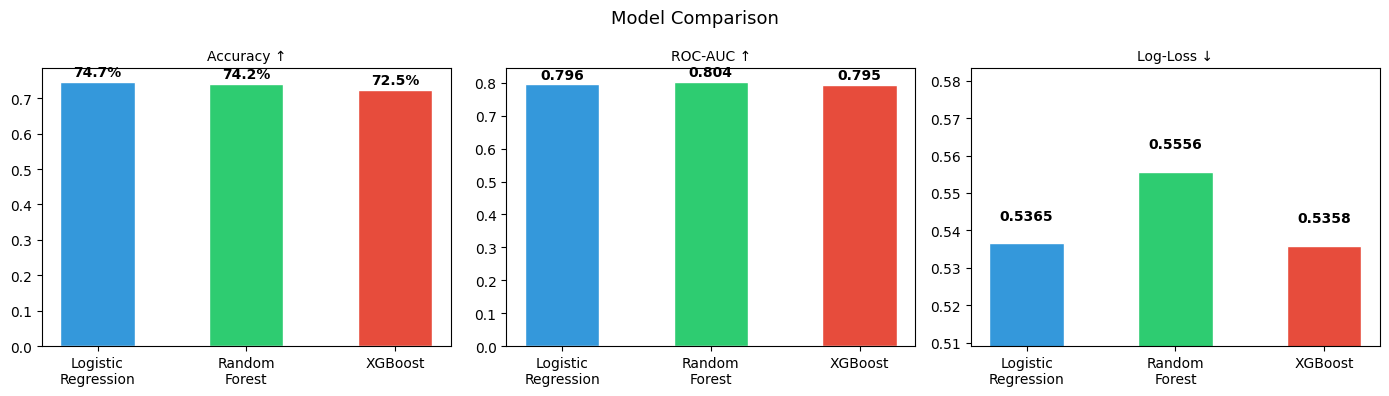

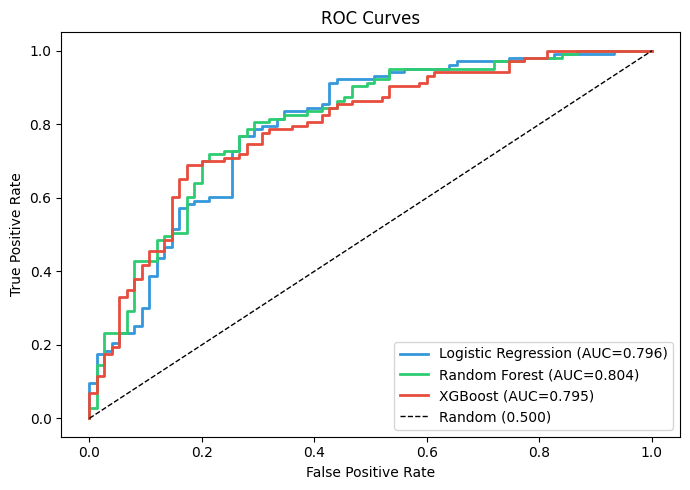

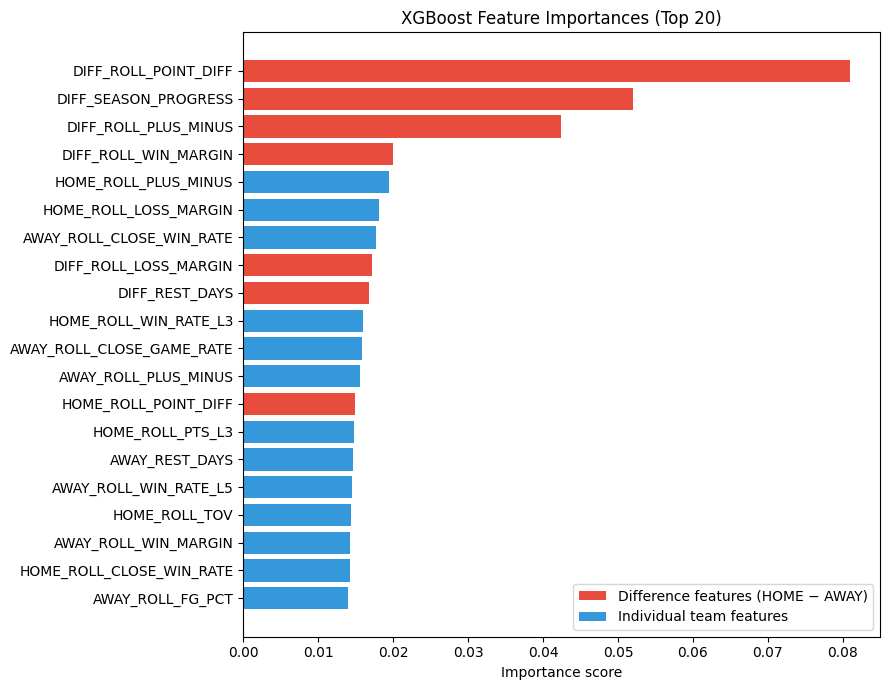

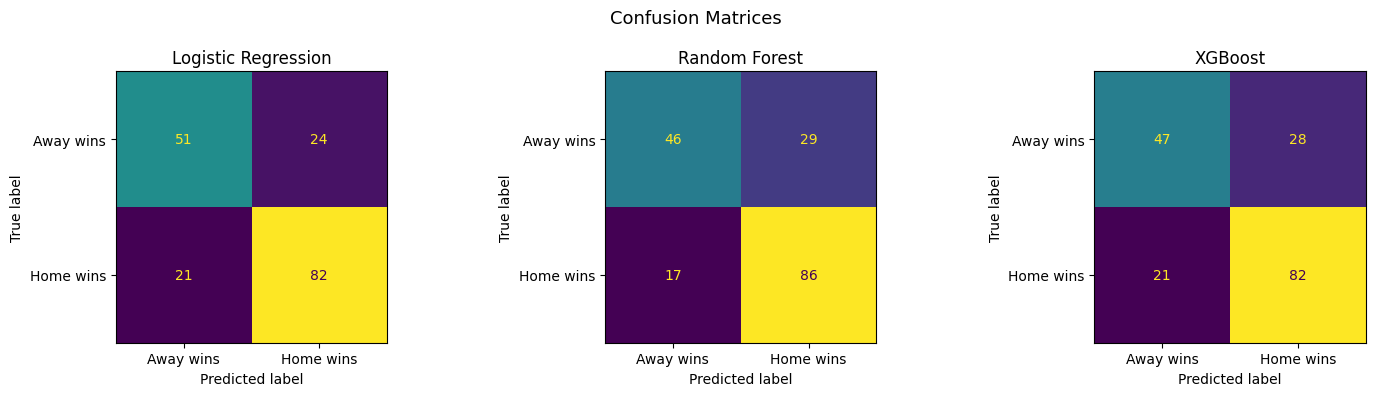


XGBoost detailed report:
              precision    recall  f1-score   support

   Away wins       0.69      0.63      0.66        75
   Home wins       0.75      0.80      0.77       103

    accuracy                           0.72       178
   macro avg       0.72      0.71      0.71       178
weighted avg       0.72      0.72      0.72       178


Found 10 NYK vs SAS game(s):

📅 2022-12-29  |  SAS (home) vs NYK (away)
   XGBoost    : SAS 65.1%  |  NYK 34.9%
   Rnd Forest : SAS 43.7%  |  NYK 56.3%
   Log Reg    : SAS 29.5%  |  NYK 70.5%
   🎯 ENSEMBLE : SAS 46.1%  |  NYK 53.9%
   Actual     : ✅ HOME won

📅 2023-01-04  |  NYK (home) vs SAS (away)
   XGBoost    : NYK 86.6%  |  SAS 13.4%
   Rnd Forest : NYK 83.6%  |  SAS 16.4%
   Log Reg    : NYK 81.4%  |  SAS 18.6%
   🎯 ENSEMBLE : NYK 83.9%  |  SAS 16.1%
   Actual     : ✅ HOME won

📅 2023-11-08  |  NYK (home) vs SAS (away)
   XGBoost    : NYK 90.5%  |  SAS 9.5%
   Rnd Forest : NYK 72.8%  |  SAS 27.2%
   Log Reg    : NYK 78.2%  |  SAS 2

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, log_loss, classification_report,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
from xgboost import XGBClassifier
from matplotlib.patches import Patch

print('✅ All imports ready')

# ── 1. LOAD ───────────────────────────────────────────────────
df = pd.read_csv('nba_games_features.csv', parse_dates=['GAME_DATE'])
df = df.sort_values('GAME_DATE').reset_index(drop=True)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── 2. FEATURE COLUMNS ───────────────────────────────────────
EXCLUDE = ['HOME_TEAM', 'AWAY_TEAM', 'HOME_WIN', 'AWAY_WIN',
           'GAME_ID', 'GAME_DATE', 'SEASON', 'SEASON_TYPE', 'TARGET']

FEATURE_COLS = [
    c for c in df.columns
    if c.startswith(('HOME_', 'AWAY_', 'DIFF_'))
    and c not in EXCLUDE
]

# Force numeric ON THE DATAFRAME before anything else
df[FEATURE_COLS] = df[FEATURE_COLS].apply(pd.to_numeric, errors='coerce')

print(f'Features : {len(FEATURE_COLS)}')
print(f'Samples  : {len(df):,}')

# ── 3. TRAIN / TEST SPLIT (time-based) ───────────────────────
CUTOFF = pd.Timestamp('2026-04-01')
train_mask = df['GAME_DATE'] < CUTOFF
test_mask  = df['GAME_DATE'] >= CUTOFF

# Use .values to get numpy arrays — bypasses ALL pandas dtype issues
X_train = df.loc[train_mask, FEATURE_COLS].copy()
X_test  = df.loc[test_mask,  FEATURE_COLS].copy()
y_train = df.loc[train_mask, 'TARGET'].values
y_test  = df.loc[test_mask,  'TARGET'].values

print(f'\nTraining : {len(X_train):,} games  ({df[train_mask]["GAME_DATE"].min().date()} → {df[train_mask]["GAME_DATE"].max().date()})')
print(f'Test     : {len(X_test):,} games   ({df[test_mask]["GAME_DATE"].min().date()} → {df[test_mask]["GAME_DATE"].max().date()})')

# ── 4. DROP ALL-NaN COLUMNS ──────────────────────────────────
all_nan_cols = X_train.columns[X_train.isnull().all()].tolist()
if all_nan_cols:
    print(f'\nDropping all-NaN columns: {all_nan_cols}')
    X_train = X_train.drop(columns=all_nan_cols)
    X_test  = X_test.drop(columns=all_nan_cols)
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in all_nan_cols]

# ── 5. FILL NaNs WITH TRAINING MEDIAN ────────────────────────
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)

# ── 6. NUCLEAR CAST — float64, no exceptions ─────────────────
X_train = X_train.astype(np.float64)
X_test  = X_test.astype(np.float64)

print(f'\nObject cols in X_train: {(X_train.dtypes == object).sum()} ← must be 0')
print(f'NaNs in X_train       : {X_train.isnull().sum().sum()} ← must be 0')
print(f'NaNs in X_test        : {X_test.isnull().sum().sum()} ← must be 0')

# ── 7. MODEL 1 — LOGISTIC REGRESSION ─────────────────────────
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)
lr_preds  = lr_pipe.predict(X_test)
lr_probs  = lr_pipe.predict_proba(X_test)[:, 1]
lr_acc    = accuracy_score(y_test, lr_preds)
lr_loss   = log_loss(y_test, lr_probs)
lr_auc    = roc_auc_score(y_test, lr_probs)
print(f'\n═══ Logistic Regression ═══')
print(f'  Accuracy : {lr_acc:.1%}  |  Log-Loss : {lr_loss:.4f}  |  AUC : {lr_auc:.4f}')

# ── 8. MODEL 2 — RANDOM FOREST ───────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=10,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds  = rf_model.predict(X_test)
rf_probs  = rf_model.predict_proba(X_test)[:, 1]
rf_acc    = accuracy_score(y_test, rf_preds)
rf_loss   = log_loss(y_test, rf_probs)
rf_auc    = roc_auc_score(y_test, rf_probs)
print(f'\n═══ Random Forest ═══')
print(f'  Accuracy : {rf_acc:.1%}  |  Log-Loss : {rf_loss:.4f}  |  AUC : {rf_auc:.4f}')

# ── 9. MODEL 3 — XGBOOST ─────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    gamma=0.1, eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_acc   = accuracy_score(y_test, xgb_preds)
xgb_loss  = log_loss(y_test, xgb_probs)
xgb_auc   = roc_auc_score(y_test, xgb_probs)
print(f'\n═══ XGBoost ═══')
print(f'  Accuracy : {xgb_acc:.1%}  |  Log-Loss : {xgb_loss:.4f}  |  AUC : {xgb_auc:.4f}')

# ── 10. COMPARISON TABLE ──────────────────────────────────────
print('\n═══ Model Comparison ═══')
results = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy' : [f'{lr_acc:.1%}', f'{rf_acc:.1%}', f'{xgb_acc:.1%}'],
    'Log-Loss' : [f'{lr_loss:.4f}', f'{rf_loss:.4f}', f'{xgb_loss:.4f}'],
    'ROC-AUC'  : [f'{lr_auc:.4f}', f'{rf_auc:.4f}', f'{xgb_auc:.4f}'],
})
print(results.to_string(index=False))

# ── 11. PLOTS ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Model Comparison', fontsize=13)
model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for ax, vals, title, fmt, lower in zip(
    axes,
    [[lr_acc, rf_acc, xgb_acc], [lr_auc, rf_auc, xgb_auc], [lr_loss, rf_loss, xgb_loss]],
    ['Accuracy ↑', 'ROC-AUC ↑', 'Log-Loss ↓'],
    ['{:.1%}', '{:.3f}', '{:.4f}'],
    [False, False, True]
):
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(min(vals)*0.95 if lower else 0, max(vals)*1.05)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                fmt.format(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(7, 5))
for name, probs, color in [
    ('Logistic Regression', lr_probs, '#3498db'),
    ('Random Forest',       rf_probs, '#2ecc71'),
    ('XGBoost',             xgb_probs,'#e74c3c'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, probs):.3f})', color=color, linewidth=2)
plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random (0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Feature importances
importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values().tail(20)
plt.figure(figsize=(9, 7))
bar_colors = ['#e74c3c' if 'DIFF' in i else '#3498db' for i in importances.index]
plt.barh(importances.index, importances.values, color=bar_colors)
plt.title('XGBoost Feature Importances (Top 20)', fontsize=12)
plt.xlabel('Importance score')
plt.legend(handles=[
    Patch(facecolor='#e74c3c', label='Difference features (HOME − AWAY)'),
    Patch(facecolor='#3498db', label='Individual team features')
])
plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices', fontsize=13)
for ax, preds, name in zip(axes,
    [lr_preds, rf_preds, xgb_preds],
    ['Logistic Regression', 'Random Forest', 'XGBoost']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=['Away wins', 'Home wins'], ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

print('\nXGBoost detailed report:')
print(classification_report(y_test, xgb_preds, target_names=['Away wins', 'Home wins']))

# ── 12. NYK vs SAS FINALS PREDICTIONS ────────────────────────
finals_games = df[
    df[['HOME_TEAM', 'AWAY_TEAM']].apply(
        lambda r: set([r['HOME_TEAM'], r['AWAY_TEAM']]) == {'NYK', 'SAS'}, axis=1
    )
].copy()

if len(finals_games) == 0:
    print('No NYK vs SAS games found in dataset.')
else:
    print(f'\nFound {len(finals_games)} NYK vs SAS game(s):')
    for _, row in finals_games.iterrows():
        game_df = pd.DataFrame(
            row[FEATURE_COLS].values.reshape(1, -1),
            columns=FEATURE_COLS
        ).astype(np.float64)   # ← cast here too, safety net

        xgb_p = xgb_model.predict_proba(game_df)[0]
        rf_p  = rf_model.predict_proba(game_df)[0]
        lr_p  = lr_pipe.predict_proba(game_df)[0]
        avg_home = (xgb_p[1] + rf_p[1] + lr_p[1]) / 3

        home   = row['HOME_TEAM']
        away   = row['AWAY_TEAM']
        actual = '✅ HOME won' if row['TARGET'] == 1 else '✅ AWAY won'

        print(f'\n📅 {str(row["GAME_DATE"])[:10]}  |  {home} (home) vs {away} (away)')
        print(f'   XGBoost    : {home} {xgb_p[1]:.1%}  |  {away} {xgb_p[0]:.1%}')
        print(f'   Rnd Forest : {home} {rf_p[1]:.1%}  |  {away} {rf_p[0]:.1%}')
        print(f'   Log Reg    : {home} {lr_p[1]:.1%}  |  {away} {lr_p[0]:.1%}')
        print(f'   🎯 ENSEMBLE : {home} {avg_home:.1%}  |  {away} {1-avg_home:.1%}')
        print(f'   Actual     : {actual}')

# ── 13. SAVE MODELS ───────────────────────────────────────────
joblib.dump(xgb_model,    'xgb_model.pkl')
joblib.dump(rf_model,     'rf_model.pkl')
joblib.dump(lr_pipe,      'lr_model.pkl')
joblib.dump(FEATURE_COLS, 'feature_cols.pkl')
print('\n✅ Models saved: xgb_model.pkl, rf_model.pkl, lr_model.pkl, feature_cols.pkl')

# Pull the last known rolling stats for each team from the dataset
def get_team_latest(team_abbr, home_or_away):
    prefix = f'{home_or_away}_'
    if home_or_away == 'HOME':
        mask = df['HOME_TEAM'] == team_abbr
    else:
        mask = df['AWAY_TEAM'] == team_abbr
    latest = df[mask].sort_values('GAME_DATE').iloc[-1]
    return latest


def predict_game(home_team, away_team, home_rest_days=2, away_rest_days=2):
    """
    Predict a game using each team's most recent rolling stats.
    Adjust rest_days to reflect actual days off before this game.
    """
    # Get latest stats for each team
    home_row = get_team_latest(home_team, 'HOME')
    away_row  = get_team_latest(away_team, 'AWAY')

    # Build a feature row
    feature_row = {}
    for col in FEATURE_COLS:
        if col.startswith('HOME_'):
            feature_row[col] = home_row.get(col, np.nan)
        elif col.startswith('AWAY_'):
            feature_row[col] = away_row.get(col, np.nan)
        elif col.startswith('DIFF_'):
            home_col = 'HOME_' + col[5:]
            away_col = 'AWAY_' + col[5:]
            feature_row[col] = home_row.get(home_col, 0) - away_row.get(away_col, 0)

    # Override rest days
    if 'HOME_REST_DAYS' in feature_row:
        feature_row['HOME_REST_DAYS'] = home_rest_days
    if 'AWAY_REST_DAYS' in feature_row:
        feature_row['AWAY_REST_DAYS'] = away_rest_days
    if 'DIFF_REST_DAYS' in feature_row:
        feature_row['DIFF_REST_DAYS'] = home_rest_days - away_rest_days

    game_df = pd.DataFrame([feature_row])[FEATURE_COLS].fillna(0)

    xgb_p = xgb_model.predict_proba(game_df)[0]
    rf_p  = rf_model.predict_proba(game_df)[0]
    lr_p  = lr_pipe.predict_proba(game_df)[0]

    # Ensemble: average the 3 models
    avg_home = (xgb_p[1] + rf_p[1] + lr_p[1]) / 3
    avg_away = 1 - avg_home

    print(f'\n🏀 {home_team} (home) vs {away_team} (away)')
    print(f'   Rest days: {home_team}={home_rest_days}d  |  {away_team}={away_rest_days}d')
    print(f'   ─────────────────────────────────')
    print(f'   XGBoost    : {home_team} {xgb_p[1]:.1%}  |  {away_team} {xgb_p[0]:.1%}')
    print(f'   Rnd Forest : {home_team} {rf_p[1]:.1%}  |  {away_team} {rf_p[0]:.1%}')
    print(f'   Log Reg    : {home_team} {lr_p[1]:.1%}  |  {away_team} {lr_p[0]:.1%}')
    print(f'   ─────────────────────────────────')
    print(f'   🎯 ENSEMBLE : {home_team} {avg_home:.1%}  |  {away_team} {avg_away:.1%}')
    winner = home_team if avg_home > 0.5 else away_team
    confidence = max(avg_home, avg_away)
    print(f'   → Predicted winner: {winner}  (confidence: {confidence:.1%})')


# ── Predict Game 2: SAS (home) vs NYK (away) ─────────────
# NYK won Game 1 on the road — now it's back in San Antonio
predict_game('SAS', 'NYK', home_rest_days=2, away_rest_days=2)

# ── Also predict if NYK closes at home (hypothetical Game 5) ─
predict_game('NYK', 'SAS', home_rest_days=2, away_rest_days=2)

✅ Imports ready
Train: 5,064 games  |  Test: 178 games

STEP 5A — Time Series Cross Validation (5 folds)

Each fold trains on older games, validates on newer ones.
This mirrors how the model will work in real life.

Logistic Regression
  Fold scores : ['62.4%', '65.3%', '63.3%', '69.3%', '65.2%']
  Mean        : 65.1%
  Std dev     : ±2.4%  (lower = more consistent)

Random Forest
  Fold scores : ['64.2%', '62.4%', '64.3%', '69.7%', '64.8%']
  Mean        : 65.1%
  Std dev     : ±2.4%  (lower = more consistent)

XGBoost
  Fold scores : ['58.4%', '62.6%', '62.2%', '69.1%', '66.5%']
  Mean        : 63.7%
  Std dev     : ±3.7%  (lower = more consistent)



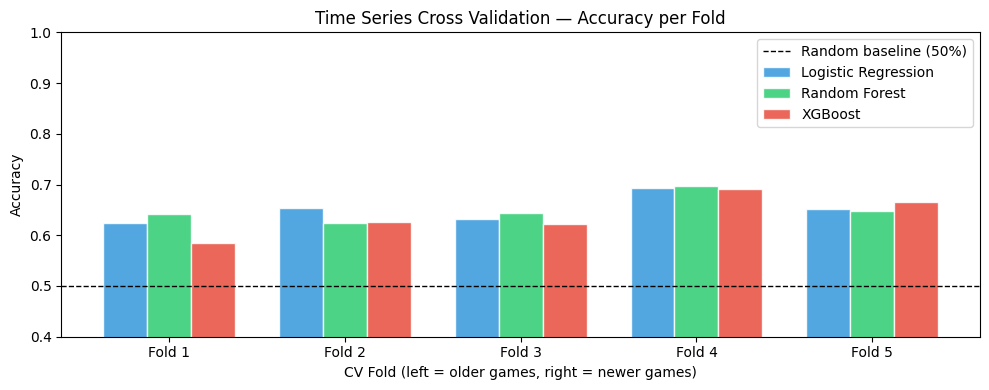

✅ Key insight: if accuracy drops in later folds, the model
   struggles with more recent game patterns — worth noting.

STEP 5B — Probability Calibration Check

If the model says 70% → the team should win ~70% of the time.
A perfectly calibrated model falls on the diagonal line.



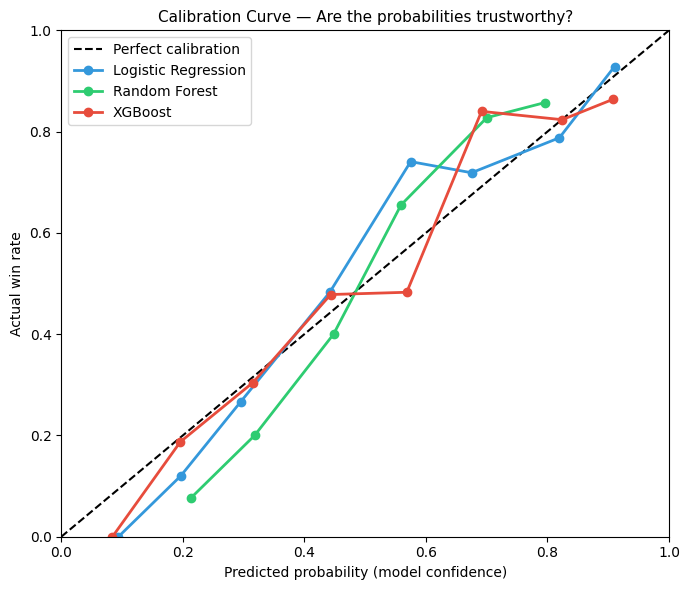

Interpretation:
  Above the diagonal → model is underconfident (predicts 60% but wins 70%)
  Below the diagonal → model is overconfident (predicts 70% but wins 60%)

STEP 5C — Playoff-only Performance

Logistic Regression    Accuracy: 69.5%  AUC: 0.7512  (n=82 games)
Random Forest          Accuracy: 69.5%  AUC: 0.7536  (n=82 games)
XGBoost                Accuracy: 68.3%  AUC: 0.7675  (n=82 games)

STEP 6 — predict_game() function

✅ Saved: train_medians.pkl, feature_cols.pkl

2026 NBA FINALS — NYK leads 2-0

🏆 PLAYOFF PREDICTION
  SAS (home, 3d rest)  vs  NYK (away, 3d rest)
  ────────────────────────────────────────────────
  XGBoost    : SAS 56.6%  |  NYK 43.4%
  Rnd Forest : SAS 49.8%  |  NYK 50.2%
  Log Reg    : SAS 35.1%  |  NYK 64.9%
  ────────────────────────────────────────────────
  🎯 ENSEMBLE : SAS 47.2%  |  NYK 52.8%
  → Predicted winner: NYK  (confidence: 52.8%)

🏆 PLAYOFF PREDICTION
  SAS (home, 2d rest)  vs  NYK (away, 2d rest)
  ──────────────────────────────────────────

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from xgboost import XGBClassifier

print('✅ Imports ready')


xgb_model    = joblib.load('xgb_model.pkl')
rf_model     = joblib.load('rf_model.pkl')
lr_pipe      = joblib.load('lr_model.pkl')
FEATURE_COLS = joblib.load('feature_cols.pkl')

df = pd.read_csv('nba_games_features.csv', parse_dates=['GAME_DATE'])
df = df.sort_values('GAME_DATE').reset_index(drop=True)
df[FEATURE_COLS] = df[FEATURE_COLS].apply(pd.to_numeric, errors='coerce')

CUTOFF      = pd.Timestamp('2026-04-01')
train_mask  = df['GAME_DATE'] < CUTOFF
test_mask   = df['GAME_DATE'] >= CUTOFF

X_train = df.loc[train_mask, FEATURE_COLS].copy()
X_test  = df.loc[test_mask,  FEATURE_COLS].copy()
y_train = df.loc[train_mask, 'TARGET'].values
y_test  = df.loc[test_mask,  'TARGET'].values

train_medians = X_train.median()
X_train = X_train.fillna(train_medians).astype(np.float64)
X_test  = X_test.fillna(train_medians).astype(np.float64)

print(f'Train: {len(X_train):,} games  |  Test: {len(X_test):,} games')
print()



print('=' * 55)
print('STEP 5A — Time Series Cross Validation (5 folds)')
print('=' * 55)
print()
print('Each fold trains on older games, validates on newer ones.')
print('This mirrors how the model will work in real life.\n')

tscv = TimeSeriesSplit(n_splits=5)

models_to_cv = {
    'Logistic Regression': lr_pipe,
    'Random Forest'      : rf_model,
    'XGBoost'            : xgb_model,
}

cv_results = {}
for name, model in models_to_cv.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=tscv, scoring='accuracy', n_jobs=-1
    )
    cv_results[name] = scores
    print(f'{name}')
    print(f'  Fold scores : {[f"{s:.1%}" for s in scores]}')
    print(f'  Mean        : {scores.mean():.1%}')
    print(f'  Std dev     : ±{scores.std():.1%}  (lower = more consistent)')
    print()

# Plot CV results
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#3498db', '#2ecc71', '#e74c3c']
x = np.arange(5)
width = 0.25

for i, (name, scores) in enumerate(cv_results.items()):
    bars = ax.bar(x + i*width, scores, width, label=name,
                  color=colors[i], alpha=0.85, edgecolor='white')

ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Random baseline (50%)')
ax.set_xlabel('CV Fold (left = older games, right = newer games)')
ax.set_ylabel('Accuracy')
ax.set_title('Time Series Cross Validation — Accuracy per Fold', fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylim(0.4, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

print('✅ Key insight: if accuracy drops in later folds, the model')
print('   struggles with more recent game patterns — worth noting.')
print()



print('=' * 55)
print('STEP 5B — Probability Calibration Check')
print('=' * 55)
print()
print('If the model says 70% → the team should win ~70% of the time.')
print('A perfectly calibrated model falls on the diagonal line.\n')

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1], 'k--', linewidth=1.5, label='Perfect calibration')

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
rf_probs  = rf_model.predict_proba(X_test)[:, 1]
lr_probs  = lr_pipe.predict_proba(X_test)[:, 1]

for name, probs, color in [
    ('Logistic Regression', lr_probs,  '#3498db'),
    ('Random Forest',       rf_probs,  '#2ecc71'),
    ('XGBoost',             xgb_probs, '#e74c3c'),
]:
    fraction_pos, mean_pred = calibration_curve(y_test, probs, n_bins=8)
    ax.plot(mean_pred, fraction_pos, marker='o', linewidth=2,
            color=color, label=name)

ax.set_xlabel('Predicted probability (model confidence)')
ax.set_ylabel('Actual win rate')
ax.set_title('Calibration Curve — Are the probabilities trustworthy?', fontsize=11)
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  Above the diagonal → model is underconfident (predicts 60% but wins 70%)')
print('  Below the diagonal → model is overconfident (predicts 70% but wins 60%)')
print()


print('=' * 55)
print('STEP 5C — Playoff-only Performance')
print('=' * 55)
print()

playoff_mask = test_mask & (df['SEASON_TYPE'] == 'Playoffs')
X_playoff = df.loc[playoff_mask, FEATURE_COLS].fillna(train_medians).astype(np.float64)
y_playoff = df.loc[playoff_mask, 'TARGET'].values

if len(X_playoff) > 0:
    for name, model, probs_fn in [
        ('Logistic Regression', lr_pipe,   lambda m,x: m.predict_proba(x)[:,1]),
        ('Random Forest',       rf_model,  lambda m,x: m.predict_proba(x)[:,1]),
        ('XGBoost',             xgb_model, lambda m,x: m.predict_proba(x)[:,1]),
    ]:
        preds = model.predict(X_playoff)
        probs = probs_fn(model, X_playoff)
        acc   = accuracy_score(y_playoff, preds)
        auc   = roc_auc_score(y_playoff, probs) if len(np.unique(y_playoff)) > 1 else float('nan')
        print(f'{name:<22} Accuracy: {acc:.1%}  AUC: {auc:.4f}  (n={len(y_playoff)} games)')
else:
    print('No playoff games in test set yet.')
print()



print('=' * 55)
print('STEP 6 — predict_game() function')
print('=' * 55)
print()

# All 30 NBA team abbreviations for validation
VALID_TEAMS = {
    'ATL','BOS','BKN','CHA','CHI','CLE','DAL','DEN','DET','GSW',
    'HOU','IND','LAC','LAL','MEM','MIA','MIL','MIN','NOP','NYK',
    'OKC','ORL','PHI','PHX','POR','SAC','SAS','TOR','UTA','WAS'
}

def predict_game(home_team: str, away_team: str,
                 home_rest: int = 2, away_rest: int = 2,
                 is_playoff: int = 1) -> dict:
    """
    Predict the winner of an NBA game using the ensemble of 3 models.

    Parameters
    ----------
    home_team  : str  — team abbreviation e.g. 'SAS', 'NYK'
    away_team  : str  — team abbreviation e.g. 'NYK', 'SAS'
    home_rest  : int  — days of rest for home team (default 2)
    away_rest  : int  — days of rest for away team (default 2)
    is_playoff : int  — 1 for playoff game, 0 for regular season

    Returns
    -------
    dict with win probabilities and predicted winner
    """


    home_team = home_team.upper().strip()
    away_team = away_team.upper().strip()

    if home_team not in VALID_TEAMS:
        raise ValueError(f'Unknown team: {home_team}. Use standard NBA abbreviations.')
    if away_team not in VALID_TEAMS:
        raise ValueError(f'Unknown team: {away_team}. Use standard NBA abbreviations.')
    if home_team == away_team:
        raise ValueError('Home and away team cannot be the same.')
    if not (0 <= home_rest <= 10):
        raise ValueError('home_rest must be between 0 and 10')
    if not (0 <= away_rest <= 10):
        raise ValueError('away_rest must be between 0 and 10')


    def get_latest_stats(team, side):
        """Pull the most recent row for this team playing as home or away."""
        col = f'{side}_TEAM'
        subset = df[df[col] == team].sort_values('GAME_DATE')
        if len(subset) == 0:
            # Fallback: try the other side
            other = 'AWAY' if side == 'HOME' else 'HOME'
            subset = df[df[f'{other}_TEAM'] == team].sort_values('GAME_DATE')
            if len(subset) == 0:
                return None, side
            return subset.iloc[-1], other   # return with actual side
        return subset.iloc[-1], side

    home_row, home_side = get_latest_stats(home_team, 'HOME')
    away_row, away_side = get_latest_stats(away_team, 'AWAY')

    if home_row is None:
        raise ValueError(f'No data found for team: {home_team}')
    if away_row is None:
        raise ValueError(f'No data found for team: {away_team}')


    feature_row = {}
    for col in FEATURE_COLS:
        if col.startswith('HOME_'):
            src_col = f'{home_side}_{col[5:]}'
            feature_row[col] = home_row.get(src_col, np.nan)
        elif col.startswith('AWAY_'):
            src_col = f'{away_side}_{col[5:]}'
            feature_row[col] = away_row.get(src_col, np.nan)
        elif col.startswith('DIFF_'):
            stat = col[5:]
            h = feature_row.get(f'HOME_{stat}', np.nan)
            a = feature_row.get(f'AWAY_{stat}', np.nan)
            feature_row[col] = (h - a) if (not np.isnan(h) and not np.isnan(a)) else np.nan


    for col in ['HOME_REST_DAYS', 'AWAY_REST_DAYS', 'HOME_IS_PLAYOFF',
                'AWAY_IS_PLAYOFF', 'DIFF_REST_DAYS', 'DIFF_IS_PLAYOFF']:
        if col in feature_row:
            if 'HOME_REST'  in col: feature_row[col] = home_rest
            if 'AWAY_REST'  in col: feature_row[col] = away_rest
            if 'DIFF_REST'  in col: feature_row[col] = home_rest - away_rest
            if 'HOME_IS_PL' in col: feature_row[col] = is_playoff
            if 'AWAY_IS_PL' in col: feature_row[col] = is_playoff
            if 'DIFF_IS_PL' in col: feature_row[col] = 0


    game_df = pd.DataFrame([feature_row])[FEATURE_COLS]
    game_df = game_df.fillna(train_medians).astype(np.float64)


    xgb_p = xgb_model.predict_proba(game_df)[0]
    rf_p  = rf_model.predict_proba(game_df)[0]
    lr_p  = lr_pipe.predict_proba(game_df)[0]

    home_probs = [xgb_p[1], rf_p[1], lr_p[1]]
    ensemble_home = np.mean(home_probs)
    ensemble_away = 1 - ensemble_home

    winner     = home_team if ensemble_home >= 0.5 else away_team
    confidence = max(ensemble_home, ensemble_away)


    game_type = '🏆 PLAYOFF' if is_playoff else '🏀 Regular Season'
    print(f'\n{game_type} PREDICTION')
    print(f'  {home_team} (home, {home_rest}d rest)  vs  {away_team} (away, {away_rest}d rest)')
    print(f'  {"─"*48}')
    print(f'  XGBoost    : {home_team} {xgb_p[1]:.1%}  |  {away_team} {xgb_p[0]:.1%}')
    print(f'  Rnd Forest : {home_team} {rf_p[1]:.1%}  |  {away_team} {rf_p[0]:.1%}')
    print(f'  Log Reg    : {home_team} {lr_p[1]:.1%}  |  {away_team} {lr_p[0]:.1%}')
    print(f'  {"─"*48}')
    print(f'  🎯 ENSEMBLE : {home_team} {ensemble_home:.1%}  |  {away_team} {ensemble_away:.1%}')
    print(f'  → Predicted winner: {winner}  (confidence: {confidence:.1%})')

    return {
        'home_team'     : home_team,
        'away_team'     : away_team,
        'home_win_prob' : round(ensemble_home, 4),
        'away_win_prob' : round(ensemble_away, 4),
        'predicted_winner': winner,
        'confidence'    : round(confidence, 4),
        'model_breakdown': {
            'xgboost'      : {'home': round(xgb_p[1], 4), 'away': round(xgb_p[0], 4)},
            'random_forest': {'home': round(rf_p[1],  4), 'away': round(rf_p[0],  4)},
            'logistic_reg' : {'home': round(lr_p[1],  4), 'away': round(lr_p[0],  4)},
        }
    }



joblib.dump(train_medians, 'train_medians.pkl')
joblib.dump(FEATURE_COLS,  'feature_cols.pkl')
print('✅ Saved: train_medians.pkl, feature_cols.pkl')
print()

# ════════════════════════════════════════════════════════════
# LIVE PREDICTIONS — 2026 NBA FINALS
# ════════════════════════════════════════════════════════════
print('=' * 55)
print('2026 NBA FINALS — NYK leads 2-0')
print('=' * 55)

# Game 1 — SAS home (already played, NYK won)
g1 = predict_game('SAS', 'NYK', home_rest=3, away_rest=3, is_playoff=1)

# Game 2 — SAS home (already played, NYK won)
g2 = predict_game('SAS', 'NYK', home_rest=2, away_rest=2, is_playoff=1)

# Game 3 — NYK home (upcoming)
g3 = predict_game('NYK', 'SAS', home_rest=2, away_rest=2, is_playoff=1)

# Game 4 — NYK home (upcoming)
g4 = predict_game('NYK', 'SAS', home_rest=1, away_rest=1, is_playoff=1)

# Game 5 — SAS home (if series continues)
g5 = predict_game('SAS', 'NYK', home_rest=1, away_rest=1, is_playoff=1)

print()
print('─' * 55)
print('SERIES SUMMARY')
print('─' * 55)
nyk_wins = sum(
    1 for g in [g1, g2, g3, g4, g5]
    if g['predicted_winner'] == 'NYK'
)
sas_wins = 5 - nyk_wins
print(f'Model predicts NYK wins {nyk_wins} of 5 simulated games')
print(f'Model predicts SAS wins {sas_wins} of 5 simulated games')
print()
print('→ Predicted Finals winner: ' +
      ('NYK 🗽' if nyk_wins >= 3 else 'SAS 🌹'))
print()
print('─' * 55)


✅ Imports ready
Loaded: 10,504 rows × 20 columns
Date range: 2022-10-18 → 2026-06-05
✅ Section A — Original features done

Section B — Momentum features (last 3 and 5 games)...
✅ Section B — Momentum features done
   New features: ROLL_WIN_RATE_L3, ROLL_WIN_RATE_L5, MOMENTUM, STREAK, ROLL_PTS_L3

Section C — Margin and close game features...
✅ Section C — Margin features done
   New features: ROLL_WIN_MARGIN, ROLL_LOSS_MARGIN, ROLL_CLOSE_WIN_RATE, ROLL_POINT_DIFF

Section D — Series context features (the big one)...
   Total games with series features: 5,242

   NYK vs SAS 2026 Finals — series context verification:
 GAME_DATE HOME_TEAM AWAY_TEAM  HOME_WIN  SERIES_GAME_NUM  HOME_SERIES_WINS  AWAY_SERIES_WINS  HOME_ELIMINATION  AWAY_ELIMINATION
2026-06-03       SAS       NYK         0              1.0               0.0               0.0               0.0               0.0
2026-06-05       SAS       NYK         0              2.0               0.0               1.0               0.0      

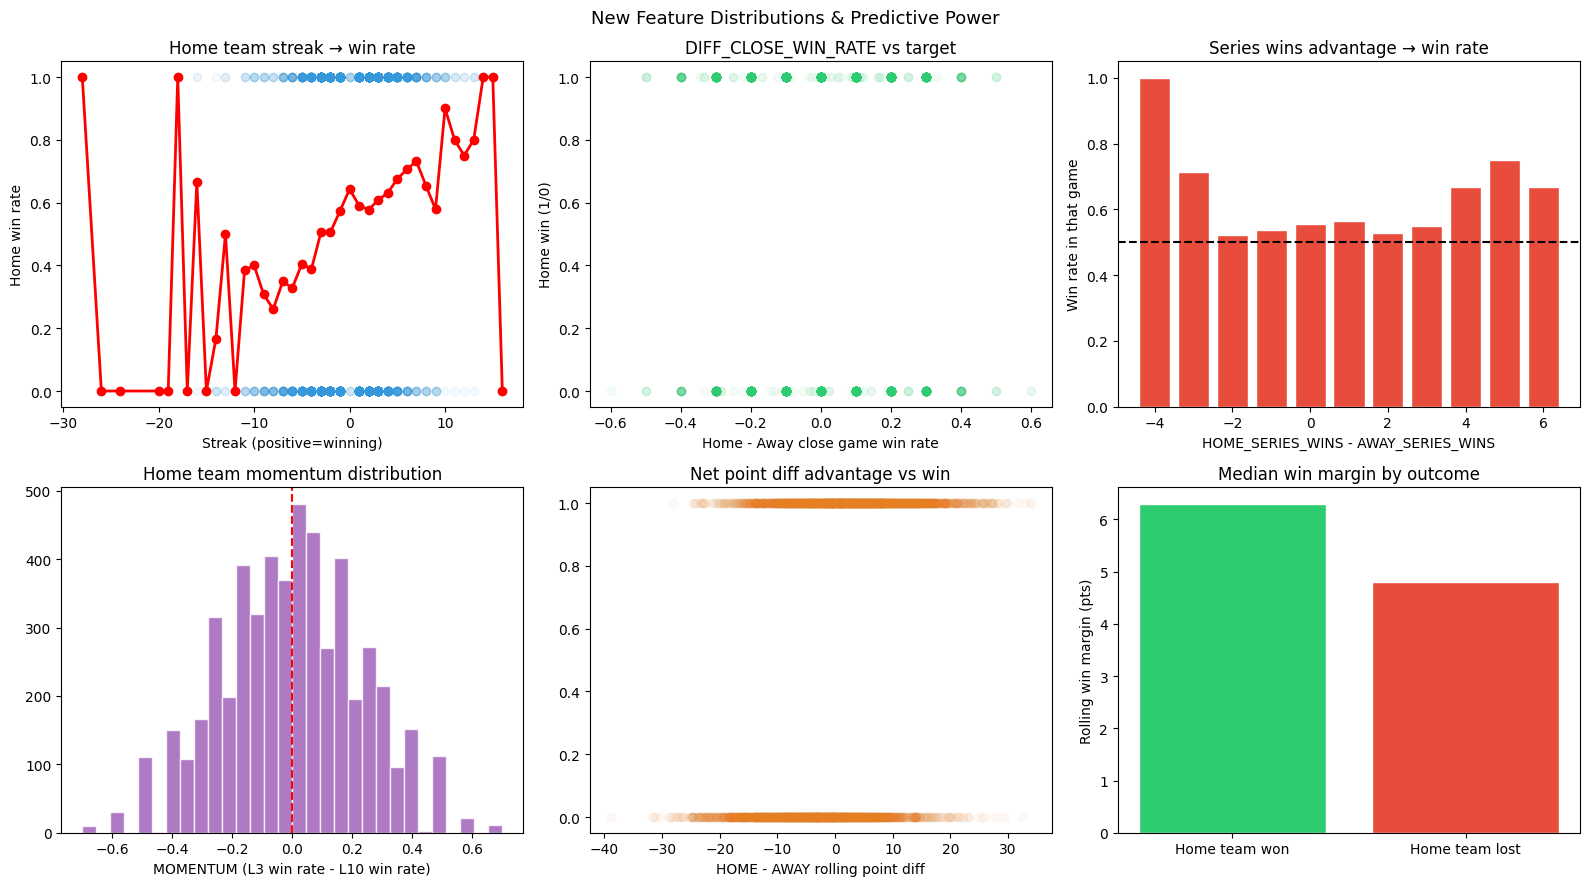

✅ Section H — Plots done

✅ Saved improved nba_games_features.csv
   Total features : ~75
   Total rows     : 5,242



In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('✅ Imports ready')

# ── LOAD RAW DATA FROM STEP 1 ─────────────────────────────────
df = pd.read_csv('nba_games_raw.csv', parse_dates=['GAME_DATE'])
df = df.sort_values('GAME_DATE').reset_index(drop=True)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range: {df["GAME_DATE"].min().date()} → {df["GAME_DATE"].max().date()}')


# ════════════════════════════════════════════════════════════
# SECTION A — ORIGINAL FEATURES (same as before)
# ════════════════════════════════════════════════════════════

ROLL_STATS = ['PTS', 'FG_PCT', 'FG3_PCT', 'REB', 'AST', 'TOV', 'PLUS_MINUS']
WINDOW     = 10

raw = df.sort_values(['TEAM_ID', 'GAME_DATE']).copy()

# Rolling averages (10 games)
for stat in ROLL_STATS:
    raw[f'ROLL_{stat}'] = raw.groupby('TEAM_ID')[stat].transform(
        lambda x: x.shift(1).rolling(WINDOW, min_periods=3).mean()
    )

# Rolling win rate (10 games)
raw['ROLL_WIN_RATE'] = raw.groupby('TEAM_ID')['WIN'].transform(
    lambda x: x.shift(1).rolling(WINDOW, min_periods=3).mean()
)

# Rest days
raw['PREV_GAME_DATE'] = raw.groupby('TEAM_ID')['GAME_DATE'].shift(1)
raw['REST_DAYS'] = (raw['GAME_DATE'] - raw['PREV_GAME_DATE']).dt.days.fillna(3).clip(upper=10)

# Playoff flag
raw['IS_PLAYOFF'] = (raw['SEASON_TYPE'] == 'Playoffs').astype(int)

# Season progress
raw['GAME_DATE_ORDINAL'] = raw['GAME_DATE'].map(pd.Timestamp.toordinal)
raw['SEASON_PROGRESS'] = raw.groupby(['TEAM_ID', 'SEASON'])['GAME_DATE_ORDINAL'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
)

print('✅ Section A — Original features done')


# ════════════════════════════════════════════════════════════
# SECTION B — IMPROVEMENT 2: SHORT WINDOW MOMENTUM FEATURES
# Fast-window rolling stats capture whether a team is hot
# RIGHT NOW, not just over the last 10 games.
# ════════════════════════════════════════════════════════════
print('\nSection B — Momentum features (last 3 and 5 games)...')

raw = raw.sort_values(['TEAM_ID', 'GAME_DATE'])

# Last 3 games win rate — are they on fire right now?
raw['ROLL_WIN_RATE_L3'] = raw.groupby('TEAM_ID')['WIN'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

# Last 5 games win rate — medium term form
raw['ROLL_WIN_RATE_L5'] = raw.groupby('TEAM_ID')['WIN'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=2).mean()
)

# Momentum delta: are they getting better or worse?
# Positive = improving (last 3 better than last 10)
raw['MOMENTUM'] = raw['ROLL_WIN_RATE_L3'] - raw['ROLL_WIN_RATE']

# Current streak: positive = win streak, negative = losing streak
def compute_streak(win_series):
    """For each game, compute the current streak heading into it."""
    streaks = []
    current = 0
    prev_results = win_series.shift(1)
    for val in prev_results:
        if pd.isna(val):
            streaks.append(0)
            current = 0
        elif val == 1:
            current = max(current + 1, 1)
            streaks.append(current)
        else:
            current = min(current - 1, -1)
            streaks.append(current)
    return streaks

raw['STREAK'] = raw.groupby('TEAM_ID')['WIN'].transform(
    lambda x: pd.Series(compute_streak(x), index=x.index)
)

# Last 3 games points scored (offensive momentum)
raw['ROLL_PTS_L3'] = raw.groupby('TEAM_ID')['PTS'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

print('✅ Section B — Momentum features done')
print(f'   New features: ROLL_WIN_RATE_L3, ROLL_WIN_RATE_L5, MOMENTUM, STREAK, ROLL_PTS_L3')


# ════════════════════════════════════════════════════════════
# SECTION C — IMPROVEMENT 3: MARGIN / CLOSE GAME FEATURES
# Playoff series are won in close games.
# Teams that win close games all season are dangerous in playoffs.
# ════════════════════════════════════════════════════════════
print('\nSection C — Margin and close game features...')

raw = raw.sort_values(['TEAM_ID', 'GAME_DATE'])

# Win margin in wins (how dominant are their victories?)
raw['WIN_MARGIN'] = raw['PLUS_MINUS'].clip(lower=0)   # 0 for losses, margin for wins
raw['LOSS_MARGIN'] = raw['PLUS_MINUS'].clip(upper=0)  # 0 for wins, margin for losses (negative)

raw['ROLL_WIN_MARGIN'] = raw.groupby('TEAM_ID')['WIN_MARGIN'].transform(
    lambda x: x.shift(1).rolling(WINDOW, min_periods=3).mean()
)

raw['ROLL_LOSS_MARGIN'] = raw.groupby('TEAM_ID')['LOSS_MARGIN'].transform(
    lambda x: x.shift(1).rolling(WINDOW, min_periods=3).mean()
)

# Close game win rate: games decided by 5 points or fewer
raw['IS_CLOSE_GAME'] = (raw['PLUS_MINUS'].abs() <= 5).astype(int)
raw['WON_CLOSE_GAME'] = ((raw['WIN'] == 1) & (raw['IS_CLOSE_GAME'] == 1)).astype(int)

raw['ROLL_CLOSE_GAME_RATE'] = raw.groupby('TEAM_ID')['IS_CLOSE_GAME'].transform(
    lambda x: x.shift(1).rolling(WINDOW, min_periods=3).mean()
)

raw['ROLL_CLOSE_WIN_RATE'] = raw.groupby('TEAM_ID')['WON_CLOSE_GAME'].transform(
    lambda x: x.shift(1).rolling(WINDOW, min_periods=3).mean()
)

# Average point differential (rolling) — net rating proxy
raw['ROLL_POINT_DIFF'] = raw.groupby('TEAM_ID')['PLUS_MINUS'].transform(
    lambda x: x.shift(1).rolling(WINDOW, min_periods=3).mean()
)

print('✅ Section C — Margin features done')
print(f'   New features: ROLL_WIN_MARGIN, ROLL_LOSS_MARGIN, ROLL_CLOSE_WIN_RATE, ROLL_POINT_DIFF')


# ════════════════════════════════════════════════════════════
# SECTION D — IMPROVEMENT 1: SERIES CONTEXT FEATURES
# This is the big one. For every playoff game, compute:
#   - How many games each team has won in the current series
#   - What game number in the series this is
#   - Whether either team is facing elimination
# For regular season games, all values are 0.
# ════════════════════════════════════════════════════════════
print('\nSection D — Series context features (the big one)...')

# Step D1: Build a game-level dataframe (one row per game, both teams)
# We need GAME_ID, DATE, both teams, and winner to track series state

# Get home and away for each game
home_df = raw[raw['IS_HOME'] == 1][['GAME_ID', 'GAME_DATE', 'SEASON', 'SEASON_TYPE',
                                      'TEAM_ABBREVIATION', 'WIN']].copy()
home_df.columns = ['GAME_ID', 'GAME_DATE', 'SEASON', 'SEASON_TYPE', 'HOME_TEAM', 'HOME_WIN']

away_df = raw[raw['IS_HOME'] == 0][['GAME_ID', 'TEAM_ABBREVIATION']].copy()
away_df.columns = ['GAME_ID', 'AWAY_TEAM']

games_meta = home_df.merge(away_df, on='GAME_ID').sort_values('GAME_DATE').reset_index(drop=True)

# Step D2: For each playoff game, identify the series
# A series = same two teams in the same season's playoffs
# We create a series key that's order-independent
games_meta['SERIES_KEY'] = games_meta.apply(
    lambda r: '_'.join(sorted([r['HOME_TEAM'], r['AWAY_TEAM']])) + '_' + r['SEASON'],
    axis=1
)

# Step D3: For each playoff game, compute series state BEFORE that game
def compute_series_features(games_meta):
    """
    For each playoff game row, compute:
    - SERIES_GAME_NUM: which game number in this series (1-7)
    - HOME_SERIES_WINS: home team wins so far in series
    - AWAY_SERIES_WINS: away team wins so far in series
    - HOME_ELIMINATION: home team facing elimination (0/1)
    - AWAY_ELIMINATION: away team facing elimination (0/1)
    - SERIES_TIED: series is tied (0/1)
    """
    results = []

    playoff_games = games_meta[games_meta['SEASON_TYPE'] == 'Playoffs'].copy()
    regular_games = games_meta[games_meta['SEASON_TYPE'] != 'Playoffs'].copy()

    # Add zeroed series features to regular season games
    for col in ['SERIES_GAME_NUM', 'HOME_SERIES_WINS', 'AWAY_SERIES_WINS',
                'HOME_ELIMINATION', 'AWAY_ELIMINATION', 'SERIES_TIED']:
        regular_games[col] = 0
    results.append(regular_games)

    # Process each playoff series independently
    for series_key, series_df in playoff_games.groupby('SERIES_KEY'):
        series_df = series_df.sort_values('GAME_DATE').reset_index(drop=True)

        home_wins_running = 0
        away_wins_running = 0

        for idx, row in series_df.iterrows():
            game_num = idx + 1  # 1-indexed

            # Record state BEFORE this game (shift: current game not counted)
            series_df.at[idx, 'SERIES_GAME_NUM']    = game_num
            series_df.at[idx, 'HOME_SERIES_WINS']   = home_wins_running
            series_df.at[idx, 'AWAY_SERIES_WINS']   = away_wins_running
            series_df.at[idx, 'HOME_ELIMINATION']   = int(away_wins_running == 3)
            series_df.at[idx, 'AWAY_ELIMINATION']   = int(home_wins_running == 3)
            series_df.at[idx, 'SERIES_TIED']        = int(home_wins_running == away_wins_running and game_num > 1)

            # Update running totals AFTER recording
            if row['HOME_WIN'] == 1:
                home_wins_running += 1
            else:
                away_wins_running += 1

        results.append(series_df)

    all_games = pd.concat(results, ignore_index=True).sort_values('GAME_DATE')
    return all_games

games_with_series = compute_series_features(games_meta)

print(f'   Total games with series features: {len(games_with_series):,}')
print()

# Verify: show NYK vs SAS 2026 Finals series progression
finals = games_with_series[
    (games_with_series['SEASON'] == '2025-26') &
    (games_with_series['SEASON_TYPE'] == 'Playoffs') &
    (games_with_series[['HOME_TEAM','AWAY_TEAM']].apply(
        lambda r: set([r['HOME_TEAM'], r['AWAY_TEAM']]) == {'NYK','SAS'}, axis=1
    ))
]
print('   NYK vs SAS 2026 Finals — series context verification:')
print(finals[['GAME_DATE','HOME_TEAM','AWAY_TEAM','HOME_WIN',
              'SERIES_GAME_NUM','HOME_SERIES_WINS','AWAY_SERIES_WINS',
              'HOME_ELIMINATION','AWAY_ELIMINATION']].to_string(index=False))
print()
print('✅ Section D — Series context features done')


# ════════════════════════════════════════════════════════════
# SECTION E — MERGE ALL FEATURES INTO 1 ROW PER GAME
# ════════════════════════════════════════════════════════════
print('\nSection E — Merging all features into final matrix...')

# All engineered features per team (from raw)
ENGINEERED = [
    # Original
    'ROLL_PTS', 'ROLL_FG_PCT', 'ROLL_FG3_PCT', 'ROLL_REB',
    'ROLL_AST', 'ROLL_TOV', 'ROLL_PLUS_MINUS', 'ROLL_WIN_RATE',
    'REST_DAYS', 'IS_PLAYOFF', 'SEASON_PROGRESS',
    # Improvement 2: Momentum
    'ROLL_WIN_RATE_L3', 'ROLL_WIN_RATE_L5', 'MOMENTUM', 'STREAK', 'ROLL_PTS_L3',
    # Improvement 3: Margin
    'ROLL_WIN_MARGIN', 'ROLL_LOSS_MARGIN',
    'ROLL_CLOSE_WIN_RATE', 'ROLL_CLOSE_GAME_RATE', 'ROLL_POINT_DIFF',
]
ENGINEERED = [f for f in ENGINEERED if f in raw.columns]

# Home team features
home_feat = raw[raw['IS_HOME'] == 1][
    ['GAME_ID', 'GAME_DATE', 'SEASON', 'SEASON_TYPE', 'TEAM_ABBREVIATION', 'WIN'] + ENGINEERED
].copy()
home_feat.columns = (
    ['GAME_ID', 'GAME_DATE', 'SEASON', 'SEASON_TYPE', 'HOME_TEAM', 'HOME_WIN'] +
    [f'HOME_{f}' for f in ENGINEERED]
)

# Away team features
away_feat = raw[raw['IS_HOME'] == 0][
    ['GAME_ID', 'TEAM_ABBREVIATION', 'WIN'] + ENGINEERED
].copy()
away_feat.columns = (
    ['GAME_ID', 'AWAY_TEAM', 'AWAY_WIN'] +
    [f'AWAY_{f}' for f in ENGINEERED]
)

# Merge home + away
feature_df = home_feat.merge(away_feat, on='GAME_ID')

# Merge series context features
series_cols = ['GAME_ID', 'SERIES_GAME_NUM', 'HOME_SERIES_WINS', 'AWAY_SERIES_WINS',
               'HOME_ELIMINATION', 'AWAY_ELIMINATION', 'SERIES_TIED']
feature_df = feature_df.merge(
    games_with_series[series_cols], on='GAME_ID', how='left'
)

# Fill NaN series features for regular season (should be 0)
for col in ['SERIES_GAME_NUM','HOME_SERIES_WINS','AWAY_SERIES_WINS',
            'HOME_ELIMINATION','AWAY_ELIMINATION','SERIES_TIED']:
    feature_df[col] = feature_df[col].fillna(0).astype(int)

feature_df = feature_df.sort_values('GAME_DATE').reset_index(drop=True)

# Target
feature_df['TARGET'] = feature_df['HOME_WIN']

print(f'   Feature matrix shape: {feature_df.shape}')
print(f'   Series columns added: SERIES_GAME_NUM, HOME_SERIES_WINS, AWAY_SERIES_WINS,')
print(f'                         HOME_ELIMINATION, AWAY_ELIMINATION, SERIES_TIED')


# ════════════════════════════════════════════════════════════
# SECTION F — DIFFERENCE FEATURES (HOME minus AWAY)
# ════════════════════════════════════════════════════════════

all_feat_cols = ENGINEERED + [
    'SERIES_WINS'  # special case handled below
]

diff_added = []
for feat in ENGINEERED:
    home_col = f'HOME_{feat}'
    away_col = f'AWAY_{feat}'
    diff_col = f'DIFF_{feat}'
    if home_col in feature_df.columns and away_col in feature_df.columns:
        feature_df[diff_col] = feature_df[home_col] - feature_df[away_col]
        diff_added.append(diff_col)

# Series wins difference is particularly important
feature_df['DIFF_SERIES_WINS'] = feature_df['HOME_SERIES_WINS'] - feature_df['AWAY_SERIES_WINS']

print(f'\n   Difference features added: {len(diff_added) + 1}')


# ════════════════════════════════════════════════════════════
# SECTION G — FILL MISSING VALUES
# ════════════════════════════════════════════════════════════

numeric_cols = feature_df.select_dtypes(include=[np.number]).columns
feature_df[numeric_cols] = feature_df[numeric_cols].fillna(
    feature_df[numeric_cols].median()
)

missing_after = feature_df.isnull().sum().sum()
print(f'\n   Missing values after fill: {missing_after}')


# ════════════════════════════════════════════════════════════
# SECTION H — QUICK VALIDATION PLOTS
# ════════════════════════════════════════════════════════════
print('\nSection H — Validation plots...')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('New Feature Distributions & Predictive Power', fontsize=13)

# 1. Streak vs win rate
axes[0,0].scatter(
    feature_df['HOME_STREAK'],
    feature_df['TARGET'],
    alpha=0.05, color='#3498db'
)
streak_win = feature_df.groupby('HOME_STREAK')['TARGET'].mean()
axes[0,0].plot(streak_win.index, streak_win.values, 'r-o', linewidth=2)
axes[0,0].set_title('Home team streak → win rate')
axes[0,0].set_xlabel('Streak (positive=winning)')
axes[0,0].set_ylabel('Home win rate')

# 2. Close game win rate correlation
axes[0,1].scatter(
    feature_df['DIFF_ROLL_CLOSE_WIN_RATE'],
    feature_df['TARGET'],
    alpha=0.05, color='#2ecc71'
)
axes[0,1].set_title('DIFF_CLOSE_WIN_RATE vs target')
axes[0,1].set_xlabel('Home - Away close game win rate')
axes[0,1].set_ylabel('Home win (1/0)')

# 3. Series wins difference vs win probability
if feature_df['DIFF_SERIES_WINS'].nunique() > 1:
    sw_win = feature_df[feature_df['IS_PLAYOFF']==1 if 'IS_PLAYOFF' in feature_df.columns
                        else feature_df.index >= 0].groupby('DIFF_SERIES_WINS')['TARGET'].mean()
    axes[0,2].bar(sw_win.index, sw_win.values, color='#e74c3c', edgecolor='white')
    axes[0,2].axhline(0.5, color='black', linestyle='--')
    axes[0,2].set_title('Series wins advantage → win rate')
    axes[0,2].set_xlabel('HOME_SERIES_WINS - AWAY_SERIES_WINS')
    axes[0,2].set_ylabel('Win rate in that game')

# 4. Momentum (L3 vs L10) distribution
axes[1,0].hist(feature_df['HOME_MOMENTUM'].dropna(), bins=30,
               color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1,0].axvline(0, color='red', linestyle='--')
axes[1,0].set_title('Home team momentum distribution')
axes[1,0].set_xlabel('MOMENTUM (L3 win rate - L10 win rate)')

# 5. Point differential rolling vs target
axes[1,1].scatter(
    feature_df['DIFF_ROLL_POINT_DIFF'],
    feature_df['TARGET'],
    alpha=0.04, color='#e67e22'
)
axes[1,1].set_title('Net point diff advantage vs win')
axes[1,1].set_xlabel('HOME - AWAY rolling point diff')

# 6. Win margin comparison
win_margin_win  = feature_df[feature_df['TARGET']==1]['HOME_ROLL_WIN_MARGIN'].median()
win_margin_loss = feature_df[feature_df['TARGET']==0]['HOME_ROLL_WIN_MARGIN'].median()
axes[1,2].bar(['Home team won', 'Home team lost'],
              [win_margin_win, win_margin_loss],
              color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1,2].set_title('Median win margin by outcome')
axes[1,2].set_ylabel('Rolling win margin (pts)')

plt.tight_layout()
plt.show()

print('✅ Section H — Plots done')


# ════════════════════════════════════════════════════════════
# SECTION I — SAVE
# ════════════════════════════════════════════════════════════
feature_df.to_csv('nba_games_features.csv', index=False)

total_features = len([c for c in feature_df.columns
                      if c.startswith(('HOME_','AWAY_','DIFF_'))
                      and c not in ['HOME_WIN','AWAY_WIN','HOME_TEAM','AWAY_TEAM']])
total_features += len(['SERIES_GAME_NUM','HOME_SERIES_WINS','AWAY_SERIES_WINS',
                        'HOME_ELIMINATION','AWAY_ELIMINATION','SERIES_TIED','DIFF_SERIES_WINS'])

print(f'\n✅ Saved improved nba_games_features.csv')
print(f'   Total features : ~{total_features}')
print(f'   Total rows     : {len(feature_df):,}')
print()
